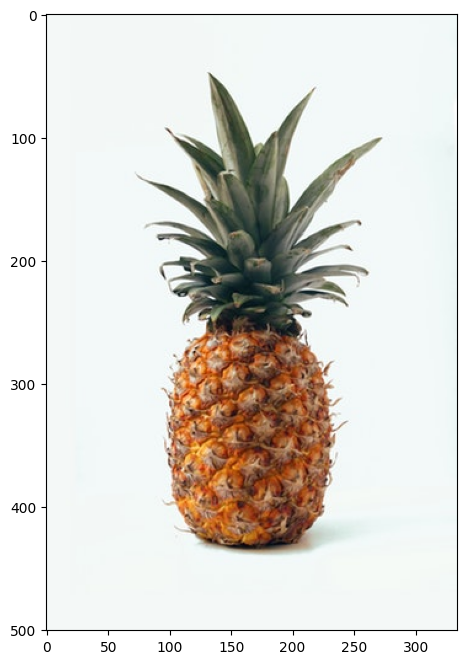

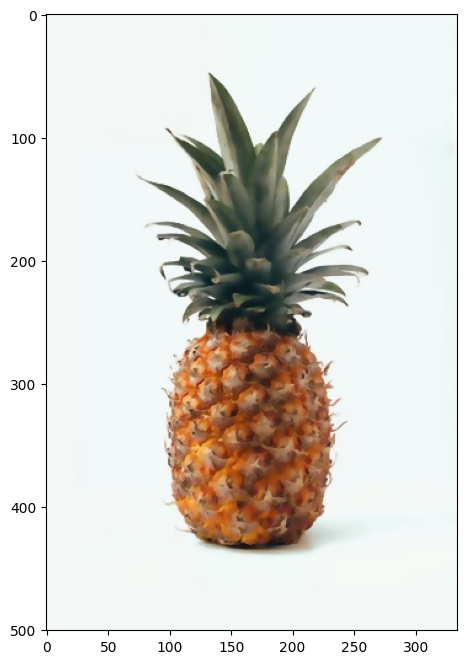

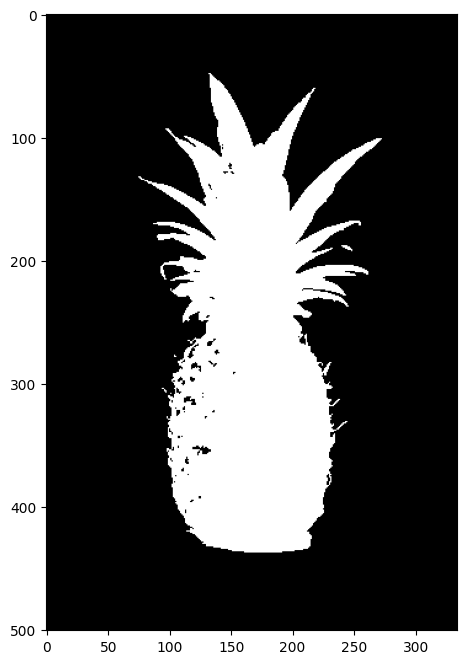

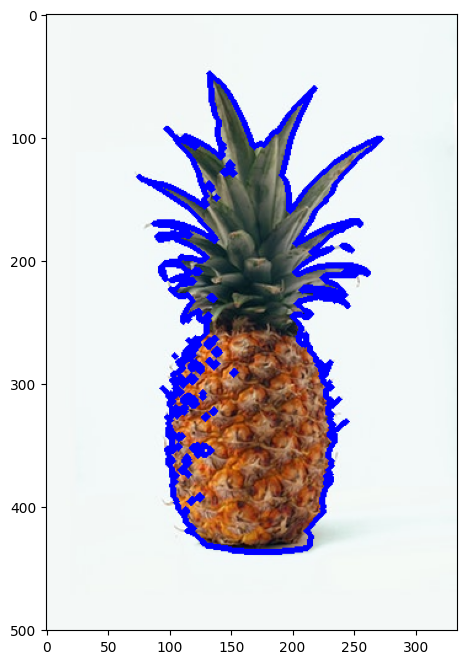

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def display(img, cmap = None):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = cmap)

img = cv2.imread('pine_apple.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display(img)


img_blur = cv2.bilateralFilter(img, d = 7, 
                               sigmaSpace = 75, sigmaColor =75)
display(img_blur)

img_gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)

a = img_gray.max()  
_, thresh = cv2.threshold(img_gray, a/2+60, a,cv2.THRESH_BINARY_INV)
display(thresh, cmap = 'gray')

contours, hierarchy = cv2.findContours(
                                   image = thresh, 
                                   mode = cv2.RETR_TREE, 
                                   method = cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(img,contours,-1,(0,0,255),3)
display(img, cmap = 'gray')


0th Contour Area :  0.0
1th Contour Area :  1.0
2th Contour Area :  0.5
3th Contour Area :  11.5
4th Contour Area :  37557.0
5th Contour Area :  2.0
6th Contour Area :  6.0
7th Contour Area :  7.0
8th Contour Area :  7.0
9th Contour Area :  2.0
10th Contour Area :  2.0
11th Contour Area :  26.5
12th Contour Area :  2.0
13th Contour Area :  8.5
14th Contour Area :  2.0
15th Contour Area :  4.0
16th Contour Area :  18.5
17th Contour Area :  9.0
18th Contour Area :  2.0
19th Contour Area :  7.5
20th Contour Area :  68.5
21th Contour Area :  4.0
22th Contour Area :  2.0
23th Contour Area :  7.0
24th Contour Area :  4.0
25th Contour Area :  7.5
26th Contour Area :  5.5
27th Contour Area :  2.0
28th Contour Area :  5.5
29th Contour Area :  18.0
30th Contour Area :  2.0
31th Contour Area :  8.5
32th Contour Area :  4.0
33th Contour Area :  2.0
34th Contour Area :  54.0
35th Contour Area :  2.0
36th Contour Area :  16.0
37th Contour Area :  12.5
38th Contour Area :  4.0
39th Contour Area :  17

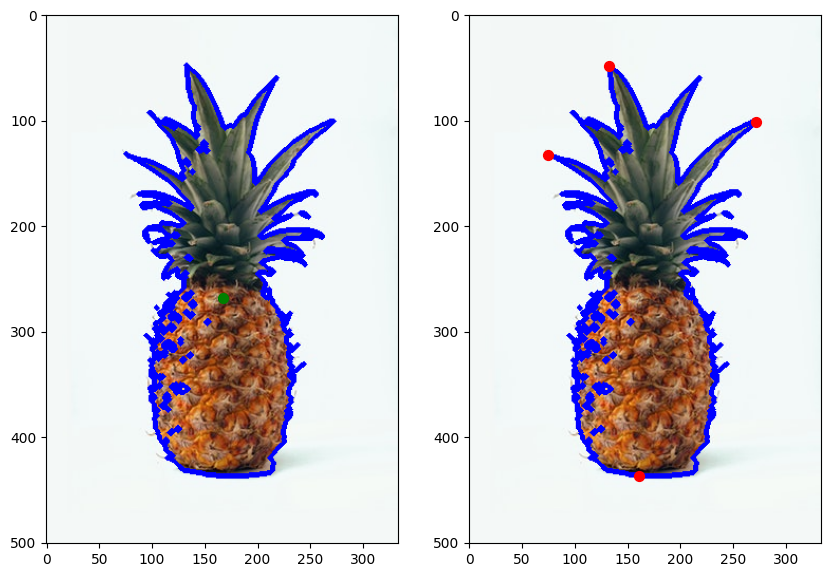

In [6]:
for i in range(len(contours)):
    print(str(i) + "th Contour Area : ", cv2.contourArea(contours[i]))

c_4 = contours[4]
M = cv2.moments(c_4)
print(M.keys())
print(len(c_4))


cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])


print(c_4.shape)
l_m = tuple(c_4[c_4[:, :, 0].argmin()][0])
r_m = tuple(c_4[c_4[:, :, 0].argmax()][0])
t_m = tuple(c_4[c_4[:, :, 1].argmin()][0])
b_m = tuple(c_4[c_4[:, :, 1].argmax()][0])
pst = [l_m, r_m, t_m, b_m]
xcor = [p[0] for p in pst]
ycor = [p[1] for p in pst]

plt.figure(figsize = (10, 16))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap = 'gray')
plt.scatter([cx], [cy], c = 'g', s = 50)
plt.subplot(1, 2, 2)
plt.imshow(img, cmap = 'gray')
plt.scatter(xcor, ycor, c = 'r', s = 50)

for c in c_4:
    x, y = c[0]
    if y == 145:
        print(c)

print(cv2.arcLength(contours[4], closed = True))
print(cv2.arcLength(contours[4], closed = False)) 

[[ 45.653477 425.46536 ]
 [ 83.89108   43.089108]
 [275.8713    62.28711 ]
 [237.6337   444.66336 ]]


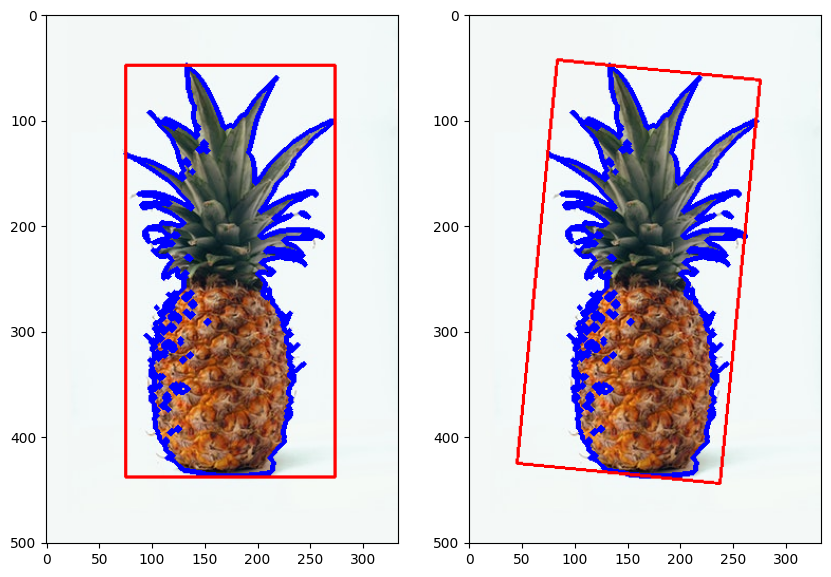

In [7]:
x, y, w, h = cv2.boundingRect(c_4)

img_copy = img.copy()
img_box = cv2.rectangle(img_copy, (x, y), (x+w, y+h), color = (255, 0, 0), thickness = 2)

rect = cv2.minAreaRect(c_4)
box = cv2.boxPoints(rect)
print(box)
box = box.astype('int')
img_copy = img.copy()

img_box_2 = cv2.drawContours(img_copy, contours = [box], 
                             contourIdx = -1, 
                             color = (255, 0, 0), thickness = 2)

plt.figure(figsize = (10, 16))
plt.subplot(1, 2, 1); plt.imshow(img_box)
plt.subplot(1, 2, 2); plt.imshow(img_box_2)


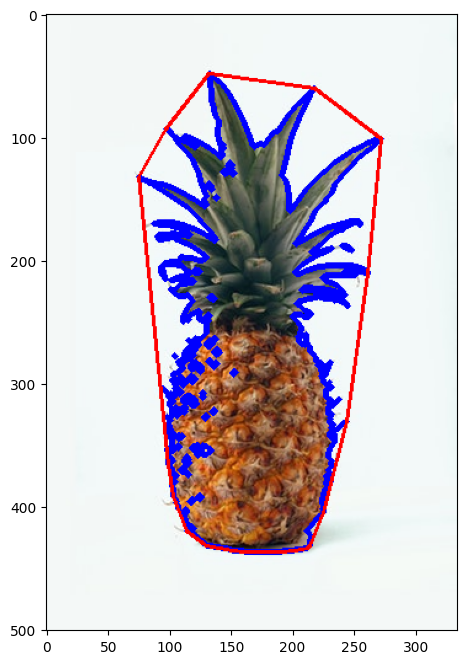

In [8]:
hull = cv2.convexHull(c_4)
img_copy = img.copy()
img_hull = cv2.drawContours(img_copy, contours = [hull], 
                            contourIdx = 0, 
                            color = (255, 0, 0), thickness = 2)
display(img_hull)

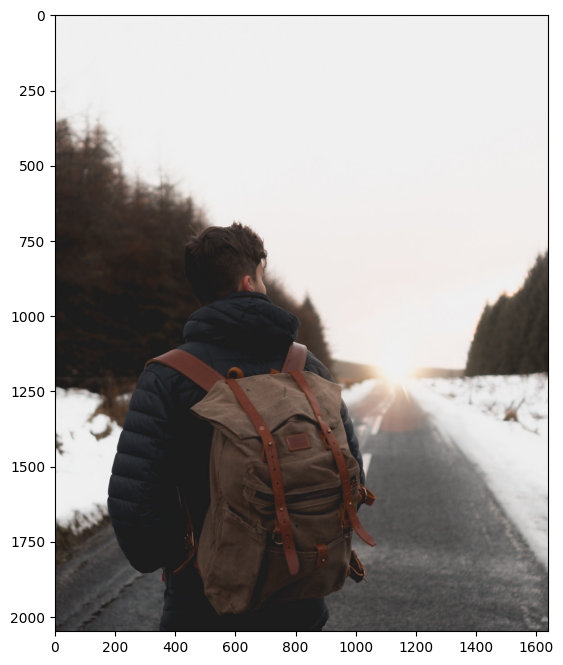

In [9]:
canvas_pic = cv2.imread('backpacker.jpg')
canvas_pic = cv2.cvtColor(canvas_pic, cv2.COLOR_BGR2RGB)
display(canvas_pic)

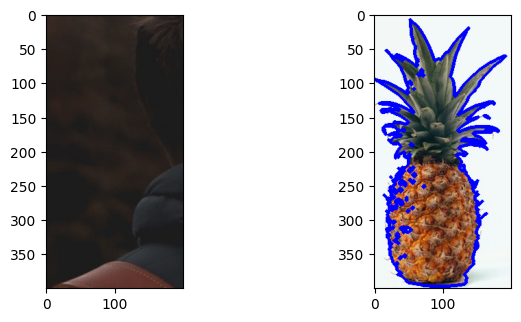

In [10]:
roi = canvas_pic[750:1150, 300:500]
img_2 = img[40:440, 80:280]
plt.figure(figsize = (6, 6))
plt.subplot(1, 3, 1); plt.imshow(roi)
plt.subplot(1, 3, 3); plt.imshow(img_2)

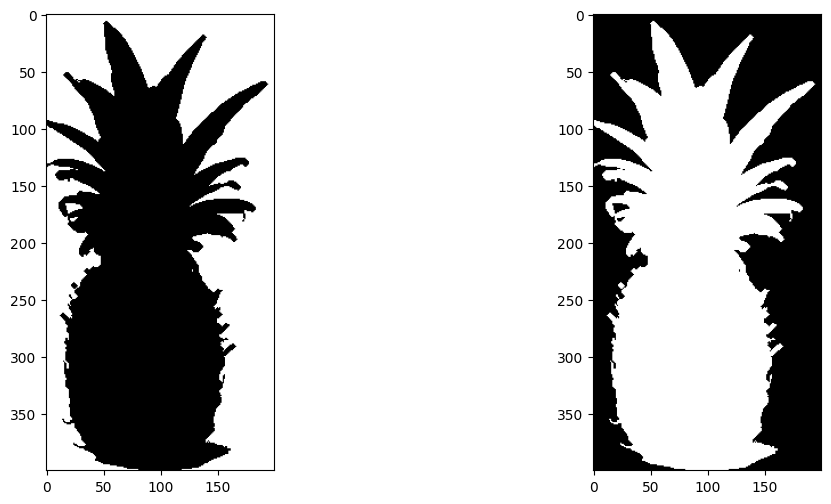

In [11]:
img_gray = cv2.cvtColor(img_2, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(img_gray, 254/2+100, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
plt.figure(figsize = (10, 6))
plt.subplot(1, 3, 1); plt.imshow(mask, cmap = 'gray')
plt.subplot(1, 3, 3); plt.imshow(mask_inv, cmap = 'gray')

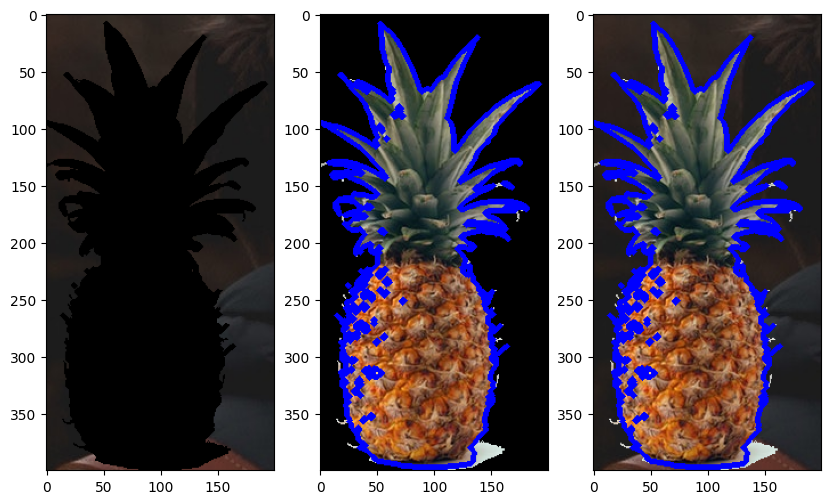

In [12]:
img_bg = cv2.bitwise_and(roi, roi, mask = mask)
img_fg = cv2.bitwise_and(img_2, img_2, mask = mask_inv)
dst = cv2.add(img_fg, img_bg)
plt.figure(figsize = (10, 6))
plt.subplot(1, 3, 1); plt.imshow(img_bg)
plt.subplot(1, 3, 2); plt.imshow(img_fg)
plt.subplot(1, 3, 3); plt.imshow(dst)

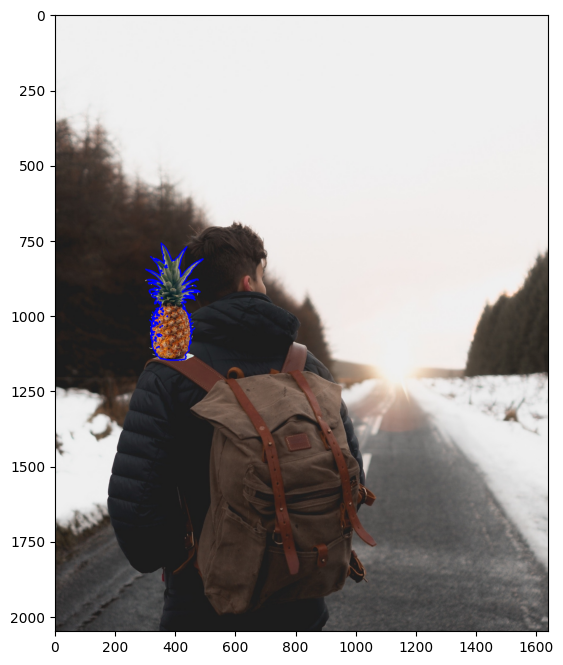

In [13]:
canvas_pic[750:1150, 300:500] = dst
display(canvas_pic)

(298, 169)
<class 'PIL.JpegImagePlugin.JpegImageFile'>


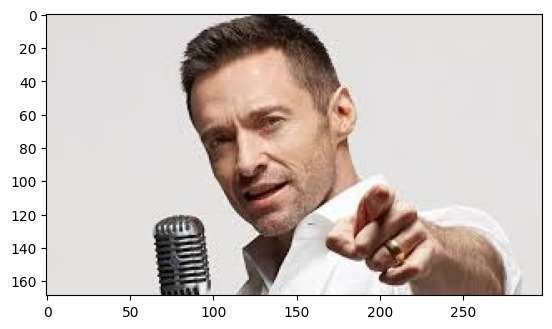

In [14]:
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import matplotlib.pyplot as plt


image = Image.open('hugh_jackman.jpg')
image.save('new_image.png')

print(image.size)
print(type(image))
plt.imshow(image)


(298, 169)
(400, 400)


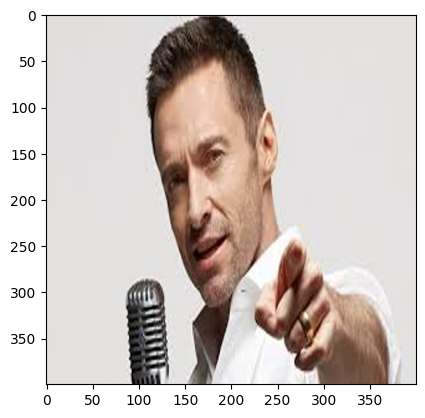

In [15]:
new_image = image.resize((400, 400))
print(image.size)
print(new_image.size)
plt.imshow(new_image);
plt.show()


In [16]:
import numpy as np
print(np.shape(image))
print(np.shape(new_image))

(169, 298, 3)
(400, 400, 3)


(298, 169)


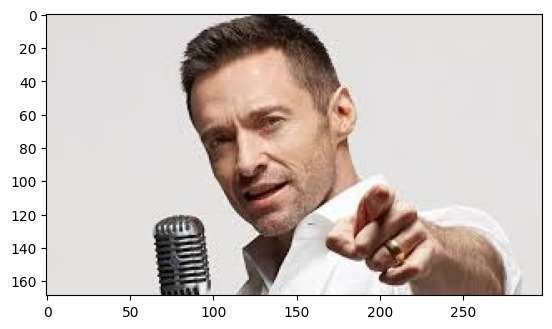

(169, 298, 3)


In [17]:
image.thumbnail((400,400))
print(image.size)
plt.imshow(image); 
plt.show()
print(np.shape(image))

(300, 300)


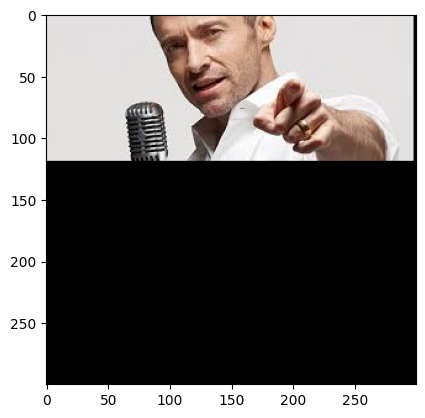

In [18]:
x1 = 0
y1 = 50
x2 = 300
y2 = 350
bbox = (x1, y1, x2, y2)

cropped_image = image.crop(bbox)
print(cropped_image.size)
plt.imshow(cropped_image)
plt.show()

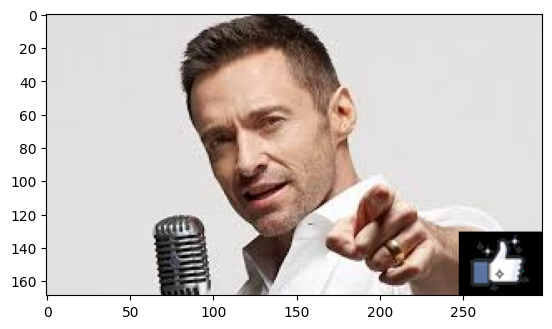

(169, 298, 3)
(38, 50, 4)
(169, 298, 3)
(38, 50, 4)
(2,)


In [19]:
logo = Image.open('thumbsup.png')
logo.thumbnail((50,50))
image_copy = image.copy()
position = ((image_copy.width - logo.width), (image_copy.height - logo.height))
image_copy.paste(logo, position)
plt.imshow(image_copy); 
plt.show()
print(np.shape(image))
print(np.shape(logo))
print(np.shape(image_copy))
print(np.shape(logo))
print(np.shape(position))

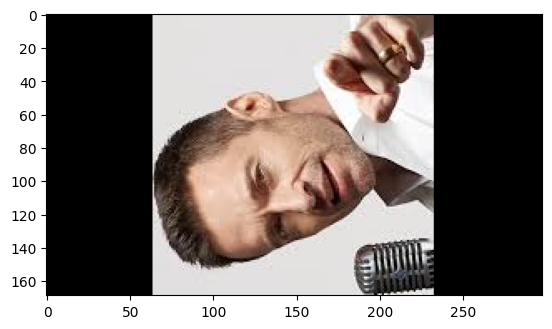

In [20]:
image_rot_90 = image.rotate(90)
plt.imshow(image_rot_90); 
plt.show()

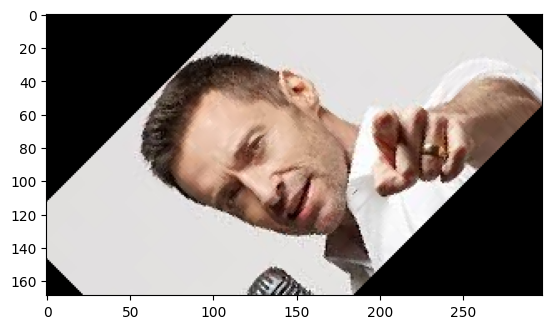

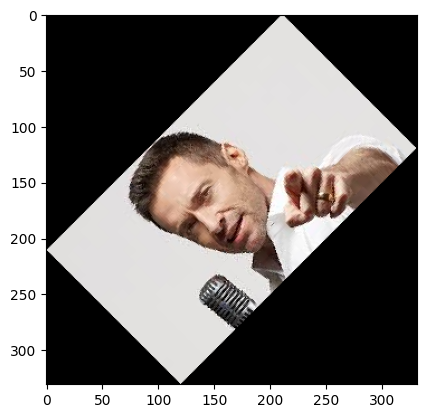

In [21]:
image_rot_45 = image.rotate(45)
plt.imshow(image_rot_45); 
plt.show()
image_rot_45 = image.rotate(45, expand = True)
plt.imshow(image_rot_45); 
plt.show()

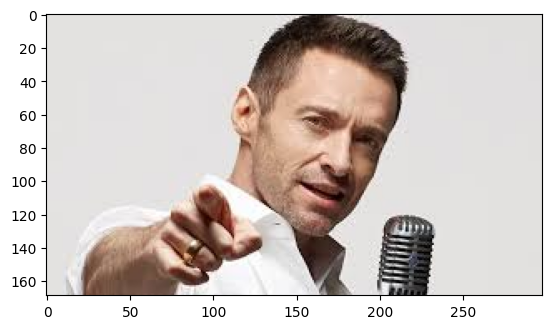

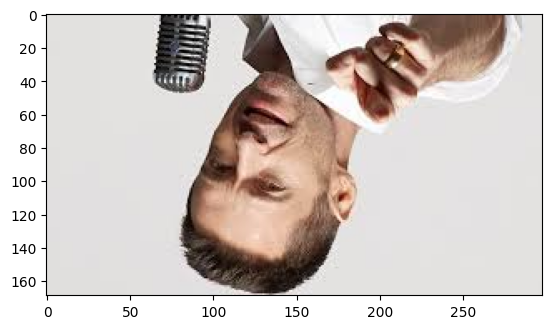

In [22]:
image_flip = image.transpose(Image.FLIP_LEFT_RIGHT) 

plt.imshow(image_flip); 
plt.show()

image_flip = image.transpose(Image.FLIP_TOP_BOTTOM) 

plt.imshow(image_flip); 
plt.show()

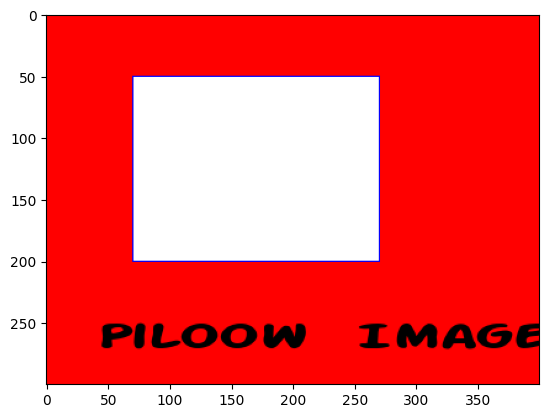

In [23]:
from PIL import Image, ImageDraw, ImageFont

blank_image = Image.new('RGBA', (400, 300), 'red')
img_draw = ImageDraw.Draw(blank_image)
img_draw.rectangle((70, 50, 270, 200), outline='blue', fill='white')
fnt = ImageFont.truetype('Action-Man/Action_Man_Extended_Bold.ttf', 30)
img_draw.text((40, 250), 'Piloow  Image', font=fnt, fill='black')

plt.imshow(blank_image); plt.show()

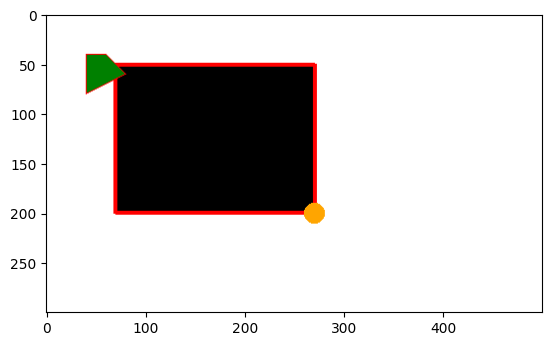

In [24]:
blank_image = Image.new('RGBA', (500, 300), 'white')

img_draw = ImageDraw.Draw(blank_image)

img_draw.rectangle((70, 50, 270, 200), outline= None, fill='black')

img_draw.line([(70,50),(270,50),(270,200),(70,200),(70,50)], fill='red', width=4)
r = 10
img_draw.ellipse((270-r,200-r, 270+r, 200+r), fill='orange')
img_draw.polygon([(40, 40), (40, 80), (80, 60), (60, 40)], fill='green', outline='red')
plt.imshow(blank_image); plt.show()

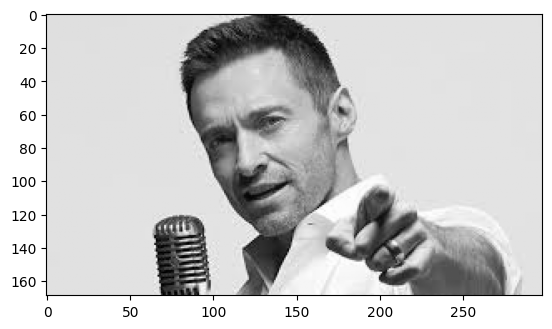

In [25]:
greyscale_image = image.convert('L')

plt.imshow(greyscale_image, cmap='gray') 
plt.show()

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

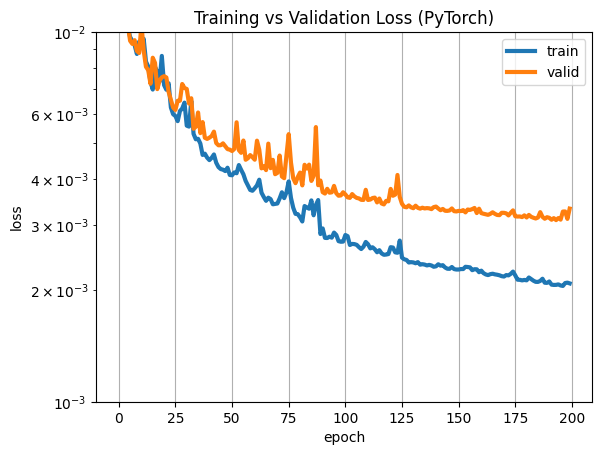

In [26]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# --------- 路徑設定（與原版一致） ---------
FTRAIN = 'data/training.csv'
FTEST = 'data/test.csv'
FLOOKUP = 'data/IdLookupTable.csv'

# --------- 裝置偵測（Mac 無 CUDA；優先使用 MPS） ---------
def get_device():
    try:
        if torch.backends.mps.is_available():
            return torch.device('mps')
    except Exception:
        pass
    return torch.device('cpu')

# --------- 資料載入（沿用你的規格與正規化） ---------
def load_dataframe(test: bool = False, cols=None) -> pd.DataFrame:
    fname = FTEST if test else FTRAIN
    df = pd.read_csv(fname)

    # 與原始程式一致：先把 Image 轉成向量（空白分隔）
    df['Image'] = df['Image'].apply(lambda im: np.fromstring(im, sep=' '))

    # 若有指定欄位，只保留這些關鍵點與 Image
    if cols:
        df = df[list(cols) + ['Image']]

    # 與原始程式一致：印出欄位計數後 dropna
    print(df.count())
    df = df.dropna()

    return df

def load_numpy(test: bool = False, cols=None):
    df = load_dataframe(test=test, cols=cols)

    # X: [N, 9216]、0~1
    X = np.vstack(df['Image'].values) / 255.0
    X = X.astype(np.float32)

    # y: 30 維關鍵點，(y - 48) / 48
    if not test:
        y = df[df.columns[:-1]].values
        y = ((y - 48) / 48).astype(np.float32)
    else:
        y = None

    print(
        "X.shape == {}; X.min == {:.3f}; X.max == {:.3f}".format(
            X.shape, X.min(), X.max()
        )
    )
    if y is not None:
        print(
            "y.shape == {}; y.min == {:.3f}; y.max == {:.3f}".format(
                y.shape, y.min(), y.max()
            )
        )
    return X, y

# --------- 模型（與 Keras 版等價：9216->100 ReLU->30） ---------
class KeypointMLP(nn.Module):
    def __init__(self, in_dim=9216, hidden=100, out_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)

# --------- 訓練迴圈（含：early stopping、ReduceLROnPlateau、grad clip） ---------
@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        preds = model(xb)
        loss = loss_fn(preds, yb)
        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_count += bs
    return total_loss / max(1, total_count)

def train_model(
    X: np.ndarray,
    y: np.ndarray,
    *,
    batch_size: int = 128,
    epochs: int = 200,
    val_split: float = 0.25,
    seed: int = 42,
    lr: float = 1e-3,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-7,
    clipnorm: float = 1.0,
    es_patience: int = 12,
    rlrop_factor: float = 0.5,
    rlrop_patience: int = 6,
    rlrop_cooldown: int = 2,
    rlrop_min_lr: float = 1e-6,
):

    # reproducibility
    rng = np.random.RandomState(seed)
    torch.manual_seed(seed)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_split, random_state=seed, shuffle=True
    )

    # to tensors
    X_train_t = torch.from_numpy(X_train)  # [N, 9216]
    y_train_t = torch.from_numpy(y_train)  # [N, 30]
    X_val_t   = torch.from_numpy(X_val)
    y_val_t   = torch.from_numpy(y_val)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, drop_last=False
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size=batch_size, shuffle=False, drop_last=False
    )

    device = get_device()
    print(f"Using device: {device}")

    model = KeypointMLP()
    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, betas=(beta1, beta2), eps=eps
    )
    loss_fn = nn.MSELoss()

    # 你的環境不支援 verbose，所以移除該參數
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=rlrop_factor,
        patience=rlrop_patience,
        cooldown=rlrop_cooldown,
        min_lr=rlrop_min_lr,
    )

    # Early Stopping 狀態
    best_val = float('inf')
    best_state = None
    wait = 0

    history = {"loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()

            # 對齊 Keras clipnorm=1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clipnorm)

            optimizer.step()

            bs = xb.size(0)
            running += loss.item() * bs
            seen += bs

        train_loss = running / max(1, seen)
        val_loss = evaluate(model, val_loader, loss_fn, device)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ReduceLROnPlateau
        prev_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        curr_lr = optimizer.param_groups[0]['lr']

        # Early Stopping
        improved = val_loss < best_val - 1e-12  # 微幅改善也算
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        lr_changed = " (lr ↓)" if curr_lr < prev_lr else ""
        print(
            f"Epoch {epoch:03d}/{epochs}  "
            f"loss={train_loss:.6f}  val_loss={val_loss:.6f}  "
            f"lr={curr_lr:.6e}{lr_changed}"
        )

        if wait >= es_patience:
            print(f"EarlyStopping: no improvement in {es_patience} epochs, restoring best weights.")
            break

    # 還原最佳權重
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def main():
    # 載入資料（與你原本相同）
    X, y = load_numpy(test=False, cols=None)

    # 訓練（對齊你的超參數）
    model, history = train_model(
        X, y,
        batch_size=128,
        epochs=200,
        val_split=0.25,
        seed=42,
        lr=1e-3,
        beta1=0.9,
        beta2=0.999,
        eps=1e-7,
        clipnorm=1.0,
        es_patience=12,
        rlrop_factor=0.5,
        rlrop_patience=6,
        rlrop_cooldown=2,
        rlrop_min_lr=1e-6,
    )

    # 繪圖（與原圖一致：log y、限制 y 範圍）
    loss = history["loss"]
    val_loss = history["val_loss"]
    plt.figure()
    plt.plot(loss, linewidth=3, label='train')
    plt.plot(val_loss, linewidth=3, label='valid')
    plt.grid(True)
    plt.legend()
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.ylim(1e-3, 1e-2)
    plt.yscale('log')
    plt.title('Training vs Validation Loss (PyTorch)')
    plt.show()


if __name__ == "__main__":
    main()


In [27]:
X_test, _ = load(test=True)    
y_pred = model.predict(X_test) 

def plot_sample(x, y, axis):
    img = x.reshape(96, 96) 
    axis.imshow(img, cmap='gray') 
    
    
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)

fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    plot_sample (X_test[i], y_pred[i], ax)

plt.show()

NameError: name 'load' is not defined

left_eye_center_x            7039
left_eye_center_y            7039
right_eye_center_x           7036
right_eye_center_y           7036
left_eye_inner_corner_x      2271
left_eye_inner_corner_y      2271
left_eye_outer_corner_x      2267
left_eye_outer_corner_y      2267
right_eye_inner_corner_x     2268
right_eye_inner_corner_y     2268
right_eye_outer_corner_x     2268
right_eye_outer_corner_y     2268
left_eyebrow_inner_end_x     2270
left_eyebrow_inner_end_y     2270
left_eyebrow_outer_end_x     2225
left_eyebrow_outer_end_y     2225
right_eyebrow_inner_end_x    2270
right_eyebrow_inner_end_y    2270
right_eyebrow_outer_end_x    2236
right_eyebrow_outer_end_y    2236
nose_tip_x                   7049
nose_tip_y                   7049
mouth_left_corner_x          2269
mouth_left_corner_y          2269
mouth_right_corner_x         2270
mouth_right_corner_y         2270
mouth_center_top_lip_x       2275
mouth_center_top_lip_y       2275
mouth_center_bottom_lip_x    7016
mouth_center_b

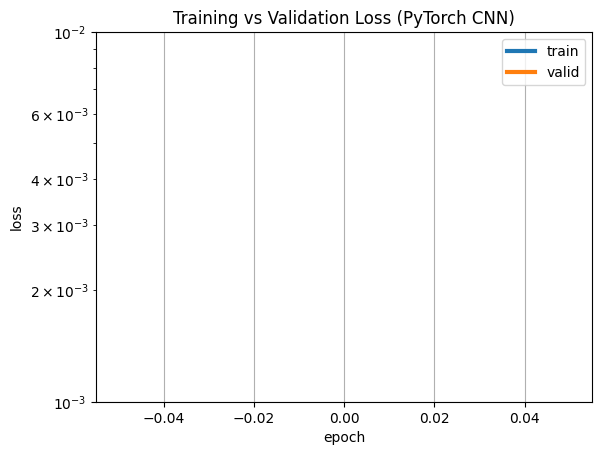

In [28]:

import os
from typing import Tuple, Optional, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ------------------------------
# Paths (align with your Keras code)
# ------------------------------
FTRAIN = "data/training.csv"
FTEST = "data/test.csv"  # not used here, but kept for parity
FLOOKUP = "data/IdLookupTable.csv"  # not used

# ------------------------------
# Device (MPS on Apple Silicon if available; otherwise CPU)
# ------------------------------
def get_device() -> torch.device:
    try:
        if torch.backends.mps.is_available():
            return torch.device("mps")
    except Exception:
        pass
    return torch.device("cpu")

# ------------------------------
# Flip index pairs (identical to your Keras subclass)
# Each pair (a, b) are indices in the 30-dim target to swap when flipping
# ------------------------------
FLIP_INDICES: List[Tuple[int, int]] = [
    (0, 2), (1, 3),
    (4, 8), (5, 9),
    (6, 10), (7, 11),
    (12, 16), (13, 17),
    (14, 18), (15, 19),
    (22, 24), (23, 25),
]

# ------------------------------
# Data loading utilities
# ------------------------------
def load_dataframe(test: bool = False, cols=None) -> pd.DataFrame:
    fname = FTEST if test else FTRAIN
    df = pd.read_csv(fname)

    # Convert Image column: string of space-separated pixels -> 1D array (len 9216)
    def parse_im(im_str: str) -> np.ndarray:
        # Some rows may contain NaNs or empty strings; handle robustly
        if isinstance(im_str, str):
            arr = np.fromstring(im_str, sep=" ")
        else:
            arr = np.array([], dtype=np.float32)
        return arr

    df["Image"] = df["Image"].apply(parse_im)

    if cols:
        df = df[list(cols) + ["Image"]]

    print(df.count())  # parity with your Keras print
    df = df.dropna()   # drop rows with missing keypoints

    # Filter out any images that didn't parse to 9216 pixels (rare but safer)
    df = df[df["Image"].apply(lambda a: a.size == 96 * 96)]

    return df.reset_index(drop=True)

def load_numpy(test: bool = False, cols=None):
    df = load_dataframe(test=test, cols=cols)

    # X: [N, 9216] scaled to [0, 1]
    X = np.vstack(df["Image"].values) / 255.0
    X = X.astype(np.float32)

    # y: 30-dim keypoints normalized to (-1, 1): (y - 48) / 48
    if not test:
        y = df[df.columns[:-1]].values.astype(np.float32)
        y = (y - 48.0) / 48.0
    else:
        y = None

    print("X.shape == {}; X.min == {:.3f}; X.max == {:.3f}".format(X.shape, X.min(), X.max()))
    if y is not None:
        print("y.shape == {}; y.min == {:.3f}; y.max == {:.3f}".format(y.shape, y.min(), y.max()))

    # reshape X to N x C x H x W (1 x 96 x 96), channel-first for PyTorch
    X = X.reshape(-1, 1, 96, 96)
    return X, y

# ------------------------------
# Dataset with on-the-fly random horizontal flip (p=0.5)
# Mirrors your ImageDataGenerator subclass behavior
# ------------------------------
class KeypointDataset(Dataset):
    def __init__(self, X: np.ndarray, y: Optional[np.ndarray] = None, augment: bool = False):
        """
        X: numpy array with shape [N, 1, 96, 96], float32 in [0, 1]
        y: numpy array with shape [N, 30] in (-1, 1) or None (for test set)
        augment: if True, randomly flip images horizontally with p=0.5 and adjust keypoints
        """
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self) -> int:
        return self.X.shape[0]

    def _flip(self, img: np.ndarray, kp: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        # img: [1, 96, 96], kp: [30]
        # Flip image horizontally (width dimension)
        img_flipped = img[:, :, ::-1].copy()

        # Invert x coordinates (every even index: 0,2,4,...,28)
        kp_flipped = kp.copy()
        kp_flipped[0::2] *= -1.0

        # Swap left/right keypoints
        for a, b in FLIP_INDICES:
            kp_flipped[a], kp_flipped[b] = kp_flipped[b].copy(), kp_flipped[a].copy()

        return img_flipped, kp_flipped

    def __getitem__(self, idx: int):
        img = self.X[idx]  # numpy [1,96,96]
        if self.y is not None:
            kp = self.y[idx]  # numpy [30]
        else:
            kp = None

        if self.augment and (np.random.rand() < 0.5):
            if kp is not None:
                img, kp = self._flip(img, kp)
            else:
                img = img[:, :, ::-1].copy()

        img_t = torch.from_numpy(img)  # float32
        if kp is None:
            return img_t
        kp_t = torch.from_numpy(kp)    # float32
        return img_t, kp_t

# ------------------------------
# Model (mirrors your Keras CNN)
# Conv2d padding matches: first conv in each block uses padding='same' -> padding=1 in PyTorch
# second conv in each block uses 'valid' -> padding=0
# ------------------------------
class KeypointCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 'same'
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=0), # 'valid'
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 'same'
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=0), # 'valid'
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 'same'
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=0), # 'valid'
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
        )

        # After blocks: 128 x 10 x 10 -> 12800
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 10 * 10, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 30),
        )

        self._init_weights()

    def _init_weights(self):
        # He (Kaiming) initialization similar to Keras he_normal
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ------------------------------
# Training / Evaluation loops
# ------------------------------
@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total = 0.0
    count = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        preds = model(xb)
        loss = loss_fn(preds, yb)
        bs = xb.size(0)
        total += loss.item() * bs
        count += bs
    return total / max(1, count)

def train(
    X: np.ndarray, y: np.ndarray,
    batch_size: int = 32,
    epochs: int = 100,
    val_split: float = 0.2,
    seed: int = 42,
):
    # Reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=val_split, random_state=seed, shuffle=True
    )

    # Datasets & Loaders
    train_ds = KeypointDataset(X_train, y_train, augment=True)
    val_ds   = KeypointDataset(X_val, y_val, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)

    device = get_device()
    print(f"Using device: {device}")

    model = KeypointCNN().to(device)
    print(model)

    # Optimizer & Loss (match your Keras setup)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=1e-3,
        momentum=0.9,
        nesterov=True
    )
    loss_fn = nn.MSELoss()

    history = {"loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            running += loss.item() * bs
            seen += bs

        train_loss = running / max(1, seen)
        val_loss = evaluate(model, val_loader, loss_fn, device)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:03d}/{epochs}  loss={train_loss:.6f}  val_loss={val_loss:.6f}  lr={optimizer.param_groups[0]['lr']:.6e}")

    return model, history

def main():
    X, y = load_numpy(test=False, cols=None)
    model, history = train(X, y, batch_size=32, epochs=100, val_split=0.2, seed=42)

    # Plot losses (same styling constraints as your Keras code)
    loss = history["loss"]
    val_loss = history["val_loss"]

    plt.figure()
    plt.plot(loss, linewidth=3, label="train")
    plt.plot(val_loss, linewidth=3, label="valid")
    plt.grid(True)
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.ylim(1e-3, 1e-2)
    plt.yscale("log")
    plt.title("Training vs Validation Loss (PyTorch CNN)")
    plt.show()

if __name__ == "__main__":
    main()

In [29]:
X_test2, _ = load2d(test=True)    
y_pred2 = model2.predict(X_test2) 

def plot_sample(x, y, axis):
    img = x.reshape(96, 96) 
    axis.imshow(img, cmap='gray') 
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='x', s=10)



fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    plot_sample(X_test[i], y_pred[i], ax)

plt.show()

NameError: name 'load2d' is not defined

NameError: name 'X_test' is not defined

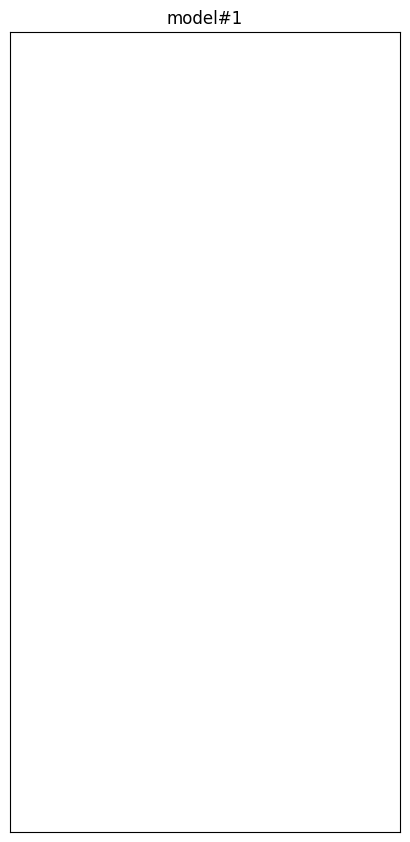

In [30]:
def plot_sample(x, y, axis):
    img = x.reshape(96, 96)       
    axis.imshow(img, cmap='gray') 
    
    
    axis.scatter(y[0::2] * 48 + 48, y[1::2] * 48 + 48, marker='o', s=40)
    
fig = plt.figure(figsize=(8, 8))

idx = 30

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)


ax = fig.add_subplot(1, 2, 1, xticks=[], yticks=[])
ax.set_title('model#1')
plot_sample(X_test[idx], y_pred[idx], ax)


ax = fig.add_subplot(1, 2, 2, xticks=[], yticks=[])
ax.set_title('model#2')
plot_sample(X_test2[idx], y_pred2[idx], ax)
 
plt.show()